In [1]:
!pip install prophet


In [2]:
from google.colab import files
uploaded = files.upload()


Saving walmart-sales-dataset-of-45stores.csv to walmart-sales-dataset-of-45stores.csv


In [3]:
import pandas as pd

df = pd.read_csv("walmart-sales-dataset-of-45stores.csv")
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [5]:
import pandas as pd

# load dataset
df = pd.read_csv("walmart-sales-dataset-of-45stores.csv")

# OPTIONAL (better results → use one store)
df = df[df['Store'] == 1]

# keep only needed columns
df = df[['Date', 'Weekly_Sales']]

# rename for Prophet
df.columns = ['ds', 'y']

# FIXED DATE ERROR HERE 👇
df['ds'] = pd.to_datetime(df['ds'], dayfirst=True)

df.head()

,ds,y
0,2010-02-05,1643690.90
1,2010-02-12,1641957.44
2,2010-02-19,1611968.17
3,2010-02-26,1409727.59
4,2010-03-05,1554806.68


In [6]:
from prophet import Prophet

model = Prophet()
model.fit(df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [9]:
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

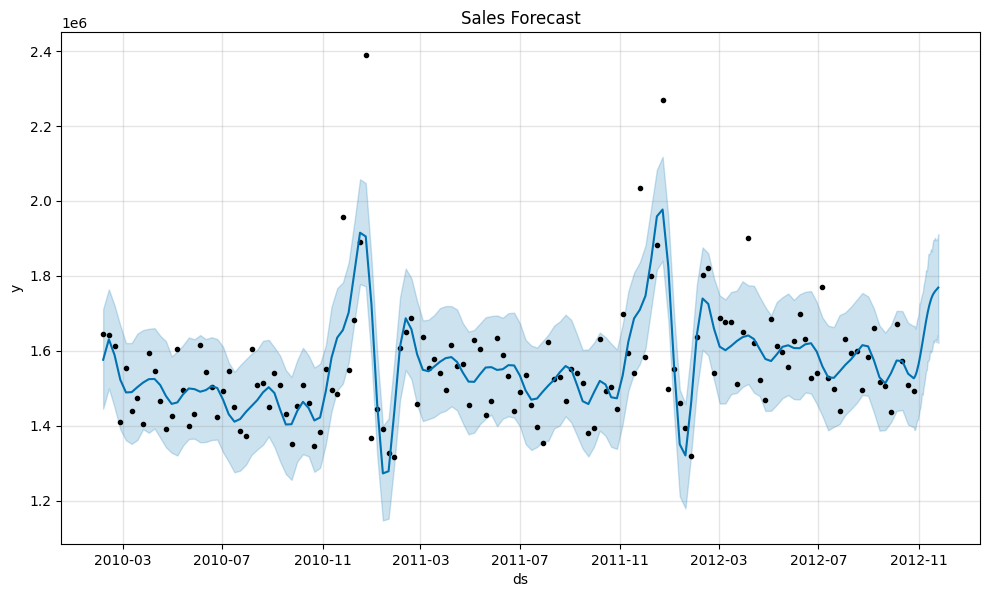

In [10]:
import matplotlib.pyplot as plt

fig = model.plot(forecast)
plt.title("Sales Forecast")
plt.show()

In [12]:
fig.savefig("sales_forecast.png")